In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [13]:
TRAIN_DIRS = [
    'archive/asl_alphabet_train',
    'ASL_Alphabet_Dataset/asl_alphabet_train',
    'dataset/asl_train'
]

train = None
for folder in TRAIN_DIRS:
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        folder,
        image_size=(64,64),
        batch_size=32,
        shuffle=True
    )
    if train is None:
        train = ds
    else:
        train = train.concatenate(ds)

Found 68356 files belonging to 29 classes.
Found 223074 files belonging to 29 classes.
Found 6 files belonging to 1 classes.


In [17]:
TEST_DIRS = [
    'archive/asl-alphabet-test',
    'ASL_Alphabet_Dataset/asl_alphabet_test',
    'dataset/asl_test',
]
test = None
for folder in TEST_DIRS:
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        folder,
        image_size=(64,64),
        batch_size=32,
        shuffle=True
    )
    if test is None:
        test = ds
    else:
        test= test.concatenate(ds)

Found 870 files belonging to 29 classes.
Found 28 files belonging to 28 classes.
Found 6 files belonging to 1 classes.


In [19]:
model = Sequential([
    Conv2D(
    32,
    (3,3),
    activation="relu",
    input_shape = (64,64,3)
),
MaxPooling2D(),

Conv2D(
    64,
    3,
    activation="relu"
),
MaxPooling2D(),
Conv2D(
    128,
    3,
    activation="relu"
),
MaxPooling2D(),
Flatten(),
Dense(
    256,
    activation="relu"
),

Dropout(
    0.3
),
Dense(
    29,
    activation="softmax"
)
])



C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer ="adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)


In [27]:
history = model.fit(
    train,
    validation_data = test,
    epochs =  8
)

Epoch 1/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 72s 34ms/step - accuracy: 0.9831 - loss: 0.0772 - val_accuracy: 0.8195 - val_loss: 0.9858
Epoch 2/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - accuracy: 0.9835 - loss: 0.0851 - val_accuracy: 0.8828 - val_loss: 0.6448
Epoch 3/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.9850 - loss: 0.0790 - val_accuracy: 0.9333 - val_loss: 0.3347
Epoch 4/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9848 - loss: 0.0884 - val_accuracy: 0.9184 - val_loss: 0.3901
Epoch 5/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.9826 - loss: 0.1018 - val_accuracy: 0.9207 - val_loss: 0.4780
Epoch 6/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.9841 - loss: 0.1052 - val_accuracy: 0.9264 - val_loss: 0.4919
Epoch 7/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.9871 - loss: 0.0872 - val_accuracy: 0.8621 - val_loss: 0.9904
Epoch 8/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9858 - loss: 0

In [28]:
loss, acc = model.evaluate(
    test
)
print("Loss:", loss)
print("Accuracy:", acc)

 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9062 - loss: 0.3179

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8908 - loss: 0.7927
Loss: 0.7927064299583435
Accuracy: 0.8908045887947083


In [29]:
history = model.fit(
    train,
    validation_data = test,
    epochs = 8
)

Epoch 1/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.9854 - loss: 0.1111 - val_accuracy: 0.8966 - val_loss: 0.7949
Epoch 2/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9874 - loss: 0.1000 - val_accuracy: 0.9425 - val_loss: 0.3847
Epoch 3/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9880 - loss: 0.0956 - val_accuracy: 0.9391 - val_loss: 0.4270
Epoch 4/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9871 - loss: 0.1086 - val_accuracy: 0.8379 - val_loss: 1.1326
Epoch 5/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9870 - loss: 0.1050 - val_accuracy: 0.9218 - val_loss: 0.5870
Epoch 6/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9879 - loss: 0.1149 - val_accuracy: 0.9264 - val_loss: 0.7770
Epoch 7/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.9880 - loss: 0.1209 - val_accuracy: 0.9425 - val_loss: 0.5189
Epoch 8/8
2137/2137 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.9896 - loss: 0

In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841,817 (14.66 MB)

 Trainable params: 1,280,605 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,561,212 (9.77 MB)

In [32]:
model.save("hand_sign_model.keras")

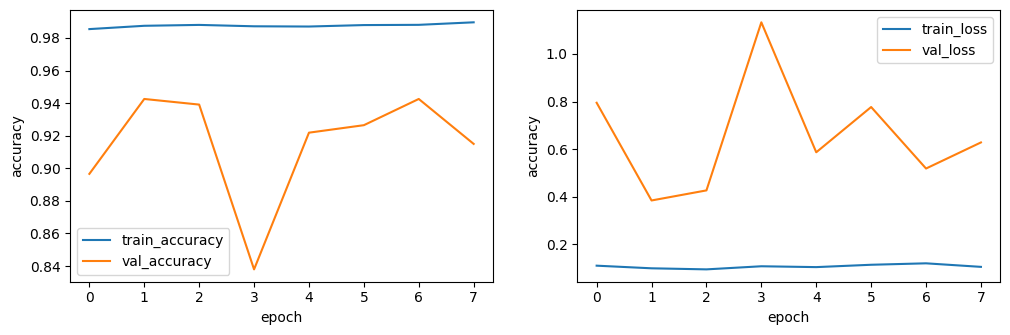

In [33]:
def plot_results(model):
  plt.figure(figsize=(12, 12))
  plt.subplot(3, 2, 1)
  plt.plot(history.history['accuracy'], label = 'train_accuracy')
  plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
  plt.xlabel('epoch')
  plt.ylabel('accuracy')
  plt.legend()
  plt.subplot(3, 2, 2)
  plt.plot(history.history['loss'], label = 'train_loss')
  plt.plot(history.history['val_loss'], label = 'val_loss')
  plt.xlabel('epoch')
  plt.ylabel('accuracy')
  plt.legend()
  plt.show()
plot_results(model)